# Pick-place-v3 PPO Split Results Visualization

This notebook visualizes the results from `pick-place_v3_ppo_split_runs`.

It uses:
```text
pick-place_v3_ppo_split_runs/results/pick-place_v3_aggregate_results.csv
pick-place_v3_ppo_split_runs/results/pick-place_v3_per_episode_results.csv
```

Run it from the folder that contains `pick-place_v3_ppo_split_runs`, or change `ROOT` below.

In [8]:
from pathlib import Path
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore

ROOT = Path('pick-place_v3_ppo_split_runs')
RESULTS = ROOT / 'results'
agg_path = RESULTS / 'pick-place_v3_aggregate_results.csv'
ep_path = RESULTS / 'pick-place_v3_per_episode_results.csv'

assert agg_path.exists(), f'Missing {agg_path}'
agg = pd.read_csv(agg_path)
episodes = pd.read_csv(ep_path) if ep_path.exists() else None

print('Aggregate shape:', agg.shape)
print('Per-episode shape:', None if episodes is None else episodes.shape)
display(agg.head())

Aggregate shape: (12, 29)
Per-episode shape: (840, 14)


,run_name,env_name,config_name,split_id,split_seed,train_seed,total_timesteps,n_envs,rollout_size,vecnormalize,...,test_avg_return,test_std_return,test_avg_steps,test_avg_first_success_step,test_episodes,success_gap,return_gap,model_path,vecnormalize_path,tensorboard_dir
0,ppo_pick-place-v3_base_pick_split0_splitseed67...,pick-place-v3,base_pick,0,67,11,6000000,4,4096,True,...,89.194004,25.791789,143.4,54.25,25,0.044444,-21.303868,pick-place_v3_ppo_split_runs\models\ppo_pick-p...,pick-place_v3_ppo_split_runs\models\ppo_pick-p...,pick-place_v3_ppo_split_runs\tensorboard
1,ppo_pick-place-v3_careful_pick_split0_splitsee...,pick-place-v3,careful_pick,0,67,11,6000000,4,4096,True,...,84.855903,7.618056,47.0,47.00,25,-0.022222,-35.500398,pick-place_v3_ppo_split_runs\models\ppo_pick-p...,pick-place_v3_ppo_split_runs\models\ppo_pick-p...,pick-place_v3_ppo_split_runs\tensorboard
2,ppo_pick-place-v3_base_pick_split1_splitseed68...,pick-place-v3,base_pick,1,68,11,6000000,4,4096,True,...,13.766218,11.312768,325.2,63.00,25,0.355556,81.110658,pick-place_v3_ppo_split_runs\models\ppo_pick-p...,pick-place_v3_ppo_split_runs\models\ppo_pick-p...,pick-place_v3_ppo_split_runs\tensorboard
3,ppo_pick-place-v3_careful_pick_split1_splitsee...,pick-place-v3,careful_pick,1,68,11,6000000,4,4096,True,...,41.249432,18.177758,132.2,40.25,25,0.200000,21.262264,pick-place_v3_ppo_split_runs\models\ppo_pick-p...,pick-place_v3_ppo_split_runs\models\ppo_pick-p...,pick-place_v3_ppo_split_runs\tensorboard
4,ppo_pick-place-v3_base_pick_split2_splitseed75...,pick-place-v3,base_pick,2,75,11,6000000,4,4096,True,...,51.755935,25.587458,41.2,41.20,25,-0.088889,1.715580,pick-place_v3_ppo_split_runs\models\ppo_pick-p...,pick-place_v3_ppo_split_runs\models\ppo_pick-p...,pick-place_v3_ppo_split_runs\tensorboard


## 1. Overview

In [9]:
print('Configs:', sorted(agg['config_name'].unique()))
print('Splits:', sorted(agg['split_id'].unique()))
print('Split seeds:', sorted(agg['split_seed'].unique()))
print('Timesteps:', sorted(agg['total_timesteps'].unique()))
display(agg[['config_name','split_id','split_seed','train_success_rate','test_success_rate','train_avg_first_success_step','test_avg_first_success_step','success_gap']].sort_values(['config_name','split_id']))

Configs: ['base_pick', 'careful_pick', 'light_entropy_pick', 'short_rollout_pick']
Splits: [np.int64(0), np.int64(1), np.int64(2)]
Split seeds: [np.int64(67), np.int64(68), np.int64(75)]
Timesteps: [np.int64(6000000)]


,config_name,split_id,split_seed,train_success_rate,test_success_rate,train_avg_first_success_step,test_avg_first_success_step,success_gap
0,base_pick,0,67,0.844444,0.8,42.342105,54.25,0.044444
2,base_pick,1,68,0.755556,0.4,57.705882,63.00,0.355556
4,base_pick,2,75,0.911111,1.0,44.219512,41.20,-0.088889
1,careful_pick,0,67,0.977778,1.0,40.272727,47.00,-0.022222
3,careful_pick,1,68,1.000000,0.8,43.155556,40.25,0.200000
5,careful_pick,2,75,1.000000,1.0,42.733333,39.60,0.000000
7,light_entropy_pick,0,67,0.955556,1.0,40.000000,48.00,-0.044444
9,light_entropy_pick,1,68,0.955556,1.0,44.651163,42.60,-0.044444
11,light_entropy_pick,2,75,0.955556,1.0,43.581395,42.40,-0.044444
6,short_rollout_pick,0,67,0.155556,0.0,45.857143,NaN,0.155556


## 2. Train/Test success rate by config and split
This shows whether each PPO configuration generalizes from the 45 train variations to the 5 held-out test variations.

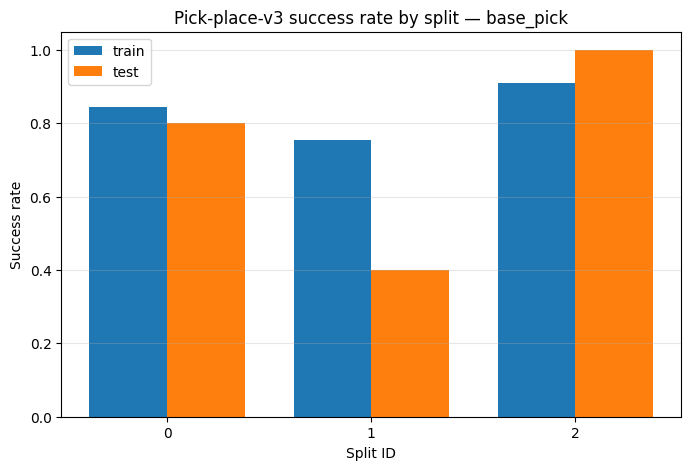

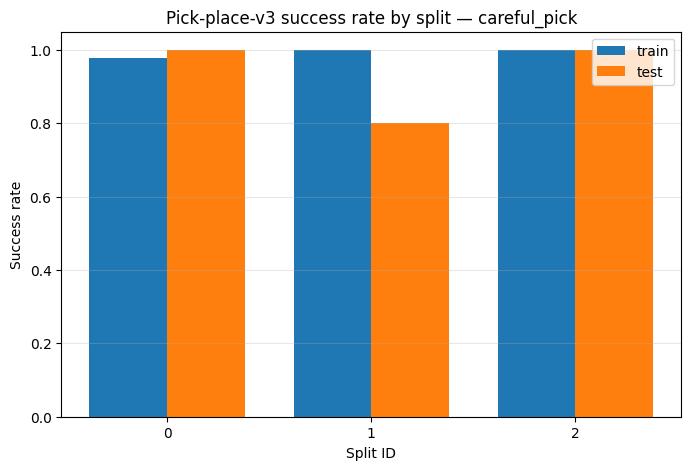

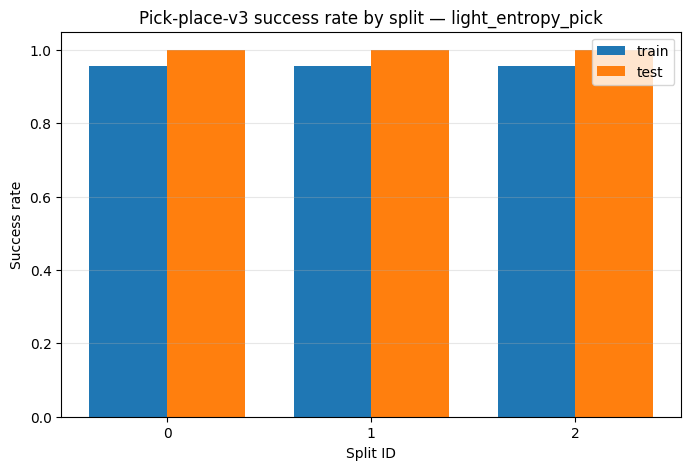

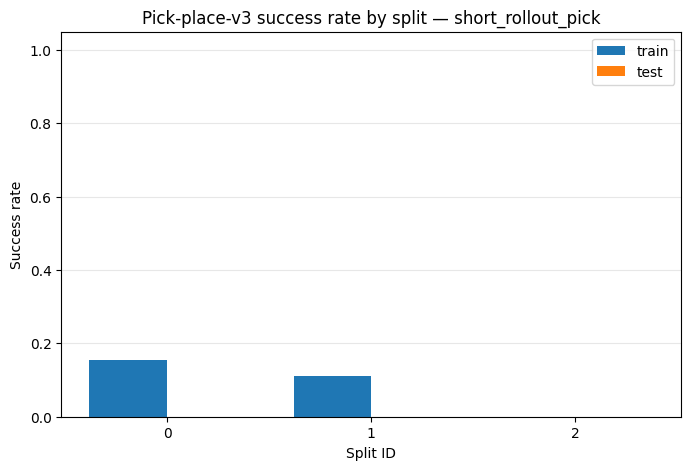

In [10]:
configs = sorted(agg['config_name'].unique())
for config in configs:
    d = agg[agg['config_name'] == config].sort_values('split_id')
    x = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(8,5))
    width = 0.38
    ax.bar(x-width/2, d['train_success_rate'], width, label='train')
    ax.bar(x+width/2, d['test_success_rate'], width, label='test')
    ax.set_title(f'Pick-place-v3 success rate by split — {config}')
    ax.set_xlabel('Split ID')
    ax.set_ylabel('Success rate')
    ax.set_ylim(0,1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(d['split_id'])
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.show()

## 3. Mean success across splits

,config_name,train_success_mean,train_success_std,test_success_mean,test_success_std,train_first_success_mean,test_first_success_mean,success_gap_mean,runs
0,base_pick,0.837037,0.078042,0.733333,0.305505,48.089167,52.816667,0.103704,3
1,careful_pick,0.992593,0.012830,0.933333,0.115470,42.053872,42.283333,0.059259,3
2,light_entropy_pick,0.955556,0.000000,1.000000,0.000000,42.744186,44.333333,-0.044444,3
3,short_rollout_pick,0.088889,0.080123,0.000000,0.000000,55.428571,NaN,0.088889,3


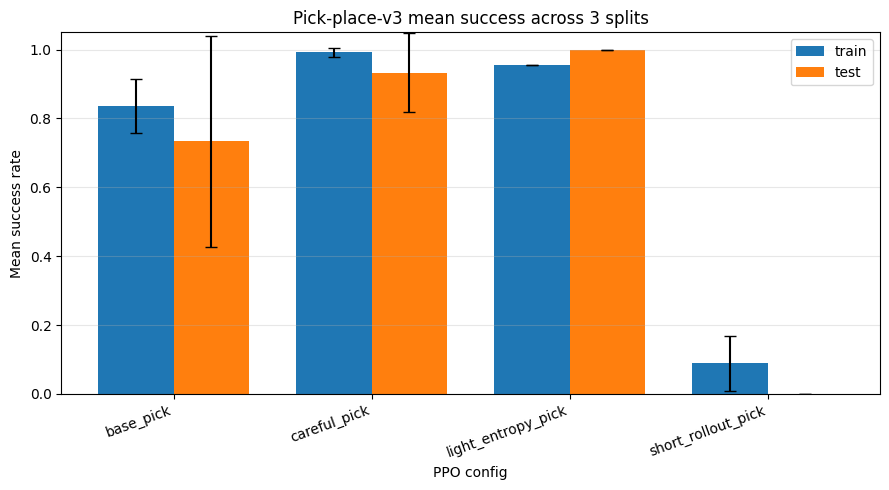

In [11]:
summary = (agg.groupby('config_name')
    .agg(
        train_success_mean=('train_success_rate','mean'),
        train_success_std=('train_success_rate','std'),
        test_success_mean=('test_success_rate','mean'),
        test_success_std=('test_success_rate','std'),
        train_first_success_mean=('train_avg_first_success_step','mean'),
        test_first_success_mean=('test_avg_first_success_step','mean'),
        success_gap_mean=('success_gap','mean'),
        runs=('split_id','count')
    ).reset_index())
display(summary)

x = np.arange(len(summary))
fig, ax = plt.subplots(figsize=(9,5))
width=0.38
ax.bar(x-width/2, summary['train_success_mean'], width, yerr=summary['train_success_std'].fillna(0), capsize=4, label='train')
ax.bar(x+width/2, summary['test_success_mean'], width, yerr=summary['test_success_std'].fillna(0), capsize=4, label='test')
ax.set_title('Pick-place-v3 mean success across 3 splits')
ax.set_xlabel('PPO config')
ax.set_ylabel('Mean success rate')
ax.set_ylim(0,1.05)
ax.set_xticks(x)
ax.set_xticklabels(summary['config_name'], rotation=20, ha='right')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 4. First success step
Lower is better. NaN means the model did not reach success in those episodes.

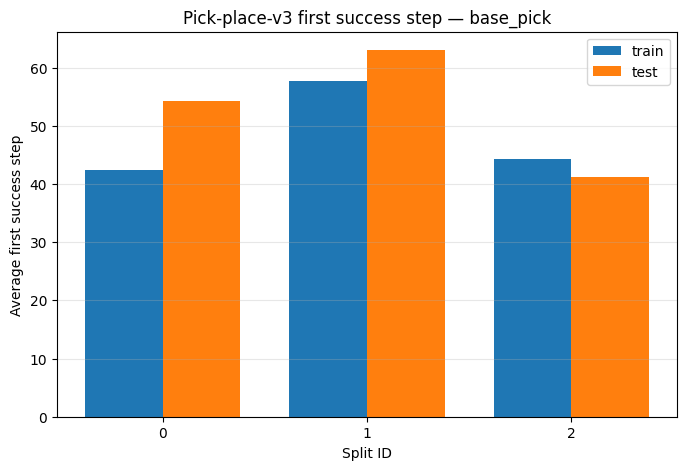

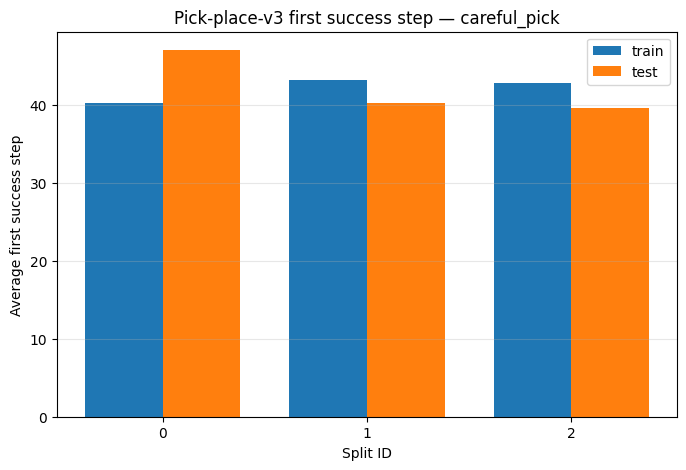

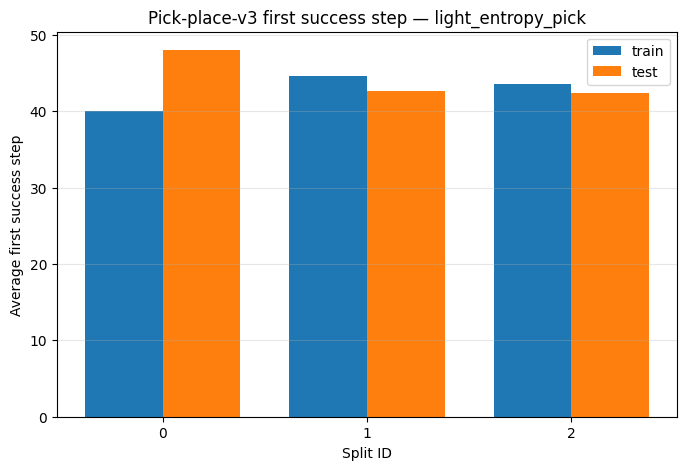

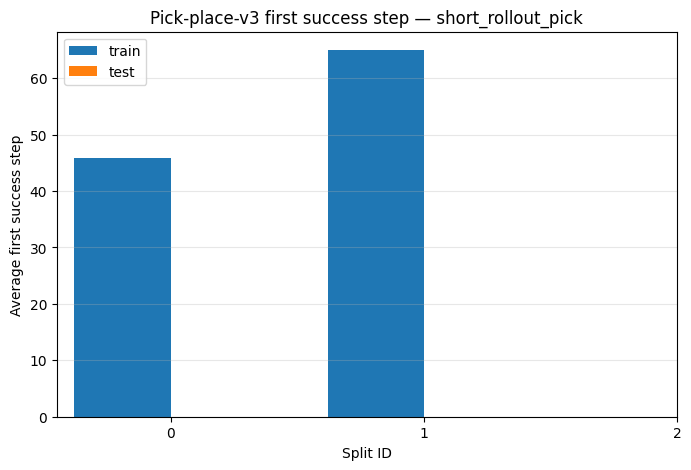

In [12]:
for config in configs:
    d = agg[agg['config_name'] == config].sort_values('split_id')
    x = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(8,5))
    width = 0.38
    ax.bar(x-width/2, d['train_avg_first_success_step'], width, label='train')
    ax.bar(x+width/2, d['test_avg_first_success_step'], width, label='test')
    ax.set_title(f'Pick-place-v3 first success step — {config}')
    ax.set_xlabel('Split ID')
    ax.set_ylabel('Average first success step')
    ax.set_xticks(x)
    ax.set_xticklabels(d['split_id'])
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.show()

## 5. Per-episode distributions
This is useful to see instability and failures.

In [13]:
if episodes is not None:
    display(episodes.head())
    print("Columns:")
    print(episodes.columns.tolist())

    # Find likely column names
    success_col = "success" if "success" in episodes.columns else None

    # group may be called group, split_group, eval_group, dataset, etc.
    possible_group_cols = ["group", "eval_group", "split_group", "dataset", "phase"]
    group_col = next((c for c in possible_group_cols if c in episodes.columns), None)

    # config may be called config, config_name, model, run_config, etc.
    possible_config_cols = ["config_name", "config", "run_config", "model_config"]
    config_col = next((c for c in possible_config_cols if c in episodes.columns), None)

    # split id may or may not exist
    possible_split_cols = ["split_id", "split", "split_seed"]
    split_col = next((c for c in possible_split_cols if c in episodes.columns), None)

    print("\nDetected:")
    print("success_col:", success_col)
    print("group_col:", group_col)
    print("config_col:", config_col)
    print("split_col:", split_col)

    if success_col is not None:
        groupby_cols = []

        if config_col is not None:
            groupby_cols.append(config_col)

        if split_col is not None:
            groupby_cols.append(split_col)

        if group_col is not None:
            groupby_cols.append(group_col)

        if len(groupby_cols) > 0:
            ep_sum = (
                episodes
                .groupby(groupby_cols)[success_col]
                .mean()
                .reset_index()
                .rename(columns={success_col: "success_rate"})
            )
            display(ep_sum.head(30))
        else:
            print("No grouping columns found. Overall success:")
            print(episodes[success_col].mean())
    else:
        print("Could not find a success column.")

else:
    print("No per-episode CSV found.")

,config,split_id,split_seed,group,task_local_idx,episode,success,return,steps,first_success_step,run_name,train_seed,total_timesteps,model_path
0,base_pick,0,67,train,0,0,1.0,13.440467,35,35.0,ppo_pick-place-v3_base_pick_split0_splitseed67...,11,6000000,pick-place_v3_ppo_split_runs\models\ppo_pick-p...
1,base_pick,0,67,train,1,0,1.0,21.733136,34,34.0,ppo_pick-place-v3_base_pick_split0_splitseed67...,11,6000000,pick-place_v3_ppo_split_runs\models\ppo_pick-p...
2,base_pick,0,67,train,2,0,1.0,120.902915,60,60.0,ppo_pick-place-v3_base_pick_split0_splitseed67...,11,6000000,pick-place_v3_ppo_split_runs\models\ppo_pick-p...
3,base_pick,0,67,train,3,0,1.0,32.858331,35,35.0,ppo_pick-place-v3_base_pick_split0_splitseed67...,11,6000000,pick-place_v3_ppo_split_runs\models\ppo_pick-p...
4,base_pick,0,67,train,4,0,1.0,91.641924,51,51.0,ppo_pick-place-v3_base_pick_split0_splitseed67...,11,6000000,pick-place_v3_ppo_split_runs\models\ppo_pick-p...


Columns:
['config', 'split_id', 'split_seed', 'group', 'task_local_idx', 'episode', 'success', 'return', 'steps', 'first_success_step', 'run_name', 'train_seed', 'total_timesteps', 'model_path']

Detected:
success_col: success
group_col: group
config_col: config
split_col: split_id


,config,split_id,group,success_rate
0,base_pick,0,test,0.800000
1,base_pick,0,train,0.844444
2,base_pick,1,test,0.400000
3,base_pick,1,train,0.755556
4,base_pick,2,test,1.000000
5,base_pick,2,train,0.911111
6,careful_pick,0,test,1.000000
7,careful_pick,0,train,0.977778
8,careful_pick,1,test,0.800000
9,careful_pick,1,train,1.000000


## 6. Save presentation figures

In [14]:
fig_dir = ROOT / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

# summary plot
fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(summary))
width=0.38
ax.bar(x-width/2, summary['train_success_mean'], width, yerr=summary['train_success_std'].fillna(0), capsize=4, label='train')
ax.bar(x+width/2, summary['test_success_mean'], width, yerr=summary['test_success_std'].fillna(0), capsize=4, label='test')
ax.set_title('Pick-place-v3 mean success across 3 splits')
ax.set_xlabel('PPO config')
ax.set_ylabel('Mean success rate')
ax.set_ylim(0,1.05)
ax.set_xticks(x)
ax.set_xticklabels(summary['config_name'], rotation=20, ha='right')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
out = fig_dir / 'pick_place_mean_success_by_config.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
plt.close(fig)
print('Saved:', out)

Saved: pick-place_v3_ppo_split_runs\figures\pick_place_mean_success_by_config.png


## 7. Suggested interpretation

- `careful_pick` is the strongest and most stable configuration.
- `light_entropy_pick` also performs well and reaches 100% test success on all three splits, but train success is slightly lower.
- `base_pick` is weaker and more split-sensitive, especially on split 1.
- `short_rollout_pick` fails badly, suggesting that the shorter rollout of 512 steps is not enough for this task/setup.
- `pick-place-v3` is harder than `button-press-v3`, but easier/more stable than the problematic basketball runs.